Loading CSV data...
Skills feature shape: (500, 60)
Category feature shape: (500, 24)
MAE: 3904896.94
MSE: 22263610722169.46
R2 Score: -0.11
Future skill chart saved: future_skill_chart.png
WordCloud saved: future_skill_wordcloud.png
✅ Future Analysis & Salary Prediction Completed Successfully!


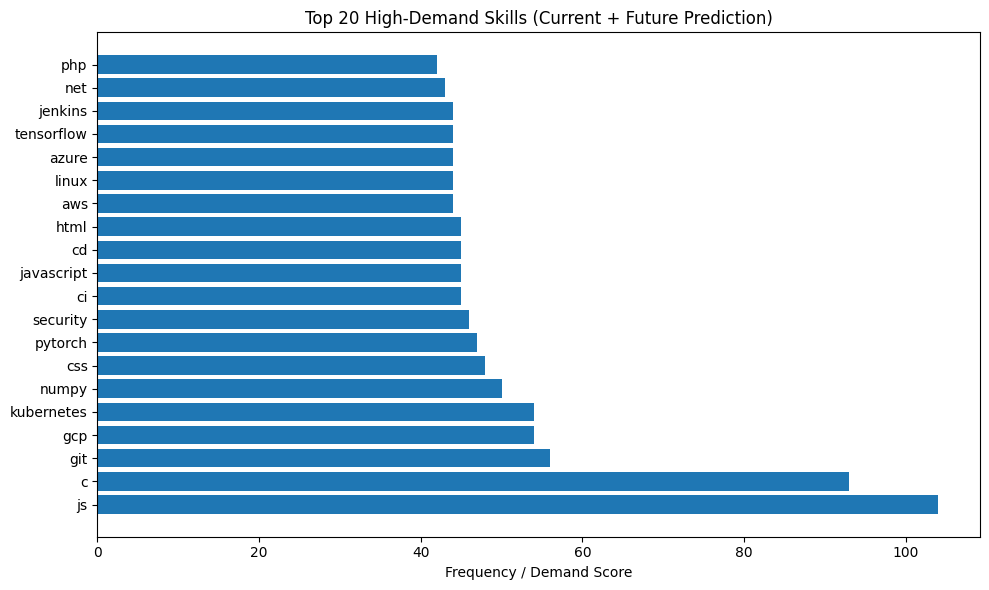

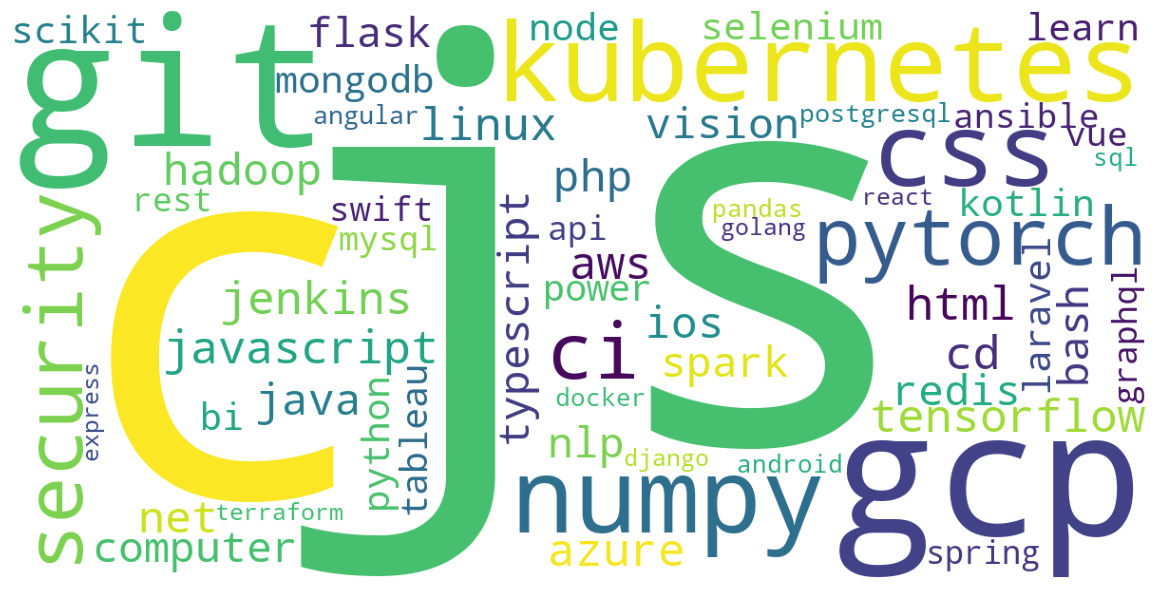

In [ ]:
import pandas as pd
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# HELPER FUNCTION

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)
    return text

# CSV load
print("Loading CSV data...")
df = pd.read_csv("jobs.csv")


# Salary column clean and make numarical value
def parse_salary(text):

    if pd.isna(text):
        return None

    original = text  
    text = str(text).lower()
    # currency Selection 
    currency = "bdt"  
    if "usd" in text or "$" in text:
        currency = "usd"
    elif "aud" in text:
        currency = "aud"
    elif "eur" in text or "€" in text:
        currency = "eur"
    elif "bdt" in text or "tk" in text or "৳" in text:
        currency = "bdt"

    text = re.sub(r'[,$€£৳]', '', text)
    text = text.replace('tk.', '').replace('tk', '')
    text = text.replace('bdt', '').replace('usd', '')
    text = text.replace('aud', '').replace('eur', '')

    # "40k", "60k" → "40000" convert
    text = re.sub(r'(\d+)k', lambda m: str(int(m.group(1)) * 1000), text)


    nums = re.findall(r'\d+', text)
    if not nums:
        return None

    nums = list(map(int, nums))

    if len(nums) >= 2:
        salary = (nums[0] + nums[1]) / 2
    else:
        salary = nums[0]

    conversion_rate = {
        "bdt": 1,
        "usd": 120,  
        "aud": 79,   
        "eur": 130   
    }

    salary_bdt = salary * conversion_rate[currency]

    return salary_bdt

df['SalaryNum'] = df['Salary'].apply(parse_salary)


# future analysis count skills and seperate unique

df['Skills_clean'] = df['Skills'].fillna('').apply(clean_text)
vectorizer = CountVectorizer()
X_skills = vectorizer.fit_transform(df['Skills_clean'])
print(f"Skills feature shape: {X_skills.shape}")
# one one unique selection
encoder = OneHotEncoder()
X_cat = encoder.fit_transform(df[['Category']])
print(f"Category feature shape: {X_cat.shape}")

# Experience → Numeric
def parse_experience(text):
    if pd.isna(text):
        return 0
    match = re.search(r'\d+', str(text))
    if match:
        return int(match.group(0))
    return 0

X_exp = df['Experience'].apply(parse_experience).values.reshape(-1,1)

# 4️⃣ Combine Features
X = hstack([X_skills, X_cat, X_exp])
y = df['SalaryNum']

# model training preperation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomForestRegressor Model use for making some disition tree and which depending by predction data and sample different
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict use for analysis future
y_pred = model.predict(X_test)

# Model Evaluation and find value
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Future Skill Demand Prediction analysis
skill_freq = df['Skills_clean'].str.split().explode().value_counts()
top_skills = skill_freq.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_skills.index, top_skills.values)
plt.title("Top 20 High-Demand Skills (Current + Future Prediction)")
plt.xlabel("Frequency / Demand Score")
plt.tight_layout()
plt.savefig("future_skill_chart.png")
print("Future skill chart saved: future_skill_chart.png")


#  Visualization this by WordCloud as image
wc = WordCloud(width=1200, height=600, background_color="white")
wc_img = wc.generate_from_frequencies(skill_freq.to_dict())

plt.figure(figsize=(12,6))
plt.imshow(wc_img)
plt.axis("off")
plt.tight_layout()
plt.savefig("future_skill_wordcloud.png")
print("WordCloud saved: future_skill_wordcloud.png")

print("✅ Future Analysis & Salary Prediction Completed Successfully!")
